In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = os.path.abspath("..")

DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

DATA_PATH = os.path.join(DATA_DIR, "executions.csv")

In [3]:
df_raw= pd.read_csv(DATA_PATH)
print("Data loaded successfully!")

print(f"Raw shape: {df_raw.shape}")
print(f"Columns:   {df_raw.columns.tolist()}\n")

Data loaded successfully!
Raw shape: (519, 22)
Columns:   ['execution_id', 'family', 'strategy', 'pattern', 'severity', 'impact_score', 'loop_depth', 'is_inside_loop', 'relative_line_position', 'co_occurring_patterns', 'execution_count_at_line', 'avg_time_ms_at_line', 'total_time_ms_at_line', 'line_dominance', 'function_call_count', 'max_recursion_depth', 'source_lines', 'complexity_class', 'complexity_ordinal', 'execution_time_ms', 'peak_memory_bytes', 'total_suggestions']



In [4]:
df_raw.head()

,execution_id,family,strategy,pattern,severity,impact_score,loop_depth,is_inside_loop,relative_line_position,co_occurring_patterns,...,total_time_ms_at_line,line_dominance,function_call_count,max_recursion_depth,source_lines,complexity_class,complexity_ordinal,execution_time_ms,peak_memory_bytes,total_suggestions
0,8cbb4282-d0ab-43e5-a233-680f2797d529,loops,restructure_loop,unused_vars,low,3.0,0,False,0.4286,unused_vars,...,0.001,0.041667,0,0,21,O(log n),2,0.137,3451,5
1,8cbb4282-d0ab-43e5-a233-680f2797d529,loops,restructure_loop,unused_vars,low,3.0,0,False,0.3333,unused_vars,...,0.002,0.041667,0,0,21,O(log n),2,0.137,3451,5
2,8cbb4282-d0ab-43e5-a233-680f2797d529,loops,restructure_loop,unused_vars,low,3.0,0,False,0.2857,unused_vars,...,0.001,0.041667,0,0,21,O(log n),2,0.137,3451,5
3,8cbb4282-d0ab-43e5-a233-680f2797d529,loops,restructure_loop,unused_vars,low,3.0,0,False,0.2381,unused_vars,...,0.001,0.041667,0,0,21,O(log n),2,0.137,3451,5
4,8cbb4282-d0ab-43e5-a233-680f2797d529,loops,restructure_loop,unused_vars,low,3.0,0,False,0.3810,unused_vars,...,0.001,0.041667,0,0,21,O(log n),2,0.137,3451,5


In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   execution_id             519 non-null    str    
 1   family                   519 non-null    str    
 2   strategy                 519 non-null    str    
 3   pattern                  519 non-null    str    
 4   severity                 519 non-null    str    
 5   impact_score             519 non-null    float64
 6   loop_depth               519 non-null    int64  
 7   is_inside_loop           519 non-null    bool   
 8   relative_line_position   519 non-null    float64
 9   co_occurring_patterns    519 non-null    str    
 10  execution_count_at_line  519 non-null    int64  
 11  avg_time_ms_at_line      519 non-null    float64
 12  total_time_ms_at_line    519 non-null    float64
 13  line_dominance           519 non-null    float64
 14  function_call_count      519 non-null

In [6]:
df_raw.describe()

,impact_score,loop_depth,relative_line_position,execution_count_at_line,avg_time_ms_at_line,total_time_ms_at_line,line_dominance,function_call_count,max_recursion_depth,source_lines,complexity_ordinal,execution_time_ms,peak_memory_bytes,total_suggestions
count,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000
mean,4.121387,0.470135,0.501117,3.398844,0.001495,0.007798,0.052314,5.589595,0.458574,21.088632,3.254335,3.791881,3727.007707,5.589595
std,3.564993,1.269852,0.209374,16.993551,0.006888,0.038054,0.066136,32.187061,1.617269,6.058582,1.779564,11.989262,385.176723,2.903727
min,2.000000,0.000000,0.032300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.017000,3076.000000,1.000000
25%,3.000000,0.000000,0.333300,1.000000,0.000000,0.000000,0.004785,0.000000,0.000000,17.000000,1.000000,0.089000,3449.000000,4.000000
50%,3.000000,0.000000,0.500000,1.000000,0.001000,0.001000,0.033333,0.000000,0.000000,21.000000,3.000000,0.214000,3654.000000,5.000000
75%,3.000000,0.000000,0.642900,1.000000,0.001000,0.001000,0.076923,0.000000,0.000000,25.000000,5.000000,0.574000,3906.000000,6.000000
max,18.000000,8.000000,1.000000,196.000000,0.092000,0.325000,0.496203,276.000000,9.000000,42.000000,6.000000,55.851000,5042.000000,14.000000


## Initial Data Exploration

<b>Cleaning - Drop Rows<b>


In [7]:
df = df_raw[df_raw["strategy"] != "none"].copy()
print(f"Dropped {len(df_raw) - len(df)} rows with strategy='none'  ->  {len(df)} rows remain")

Dropped 0 rows with strategy='none'  ->  519 rows remain


<b>Cleaning - Drop Columns<b>

In [8]:
drop_cols = [
    "execution_id", "family", "complexity_class",
    "total_time_ms_at_line", "co_occurring_patterns",
    "source_lines", "execution_time_ms", "peak_memory_bytes",
    "total_suggestions"
]

df = df.drop(columns=drop_cols, errors="ignore")
df.head()

,strategy,pattern,severity,impact_score,loop_depth,is_inside_loop,relative_line_position,execution_count_at_line,avg_time_ms_at_line,line_dominance,function_call_count,max_recursion_depth,complexity_ordinal
0,restructure_loop,unused_vars,low,3.0,0,False,0.4286,1,0.001,0.041667,0,0,2
1,restructure_loop,unused_vars,low,3.0,0,False,0.3333,1,0.002,0.041667,0,0,2
2,restructure_loop,unused_vars,low,3.0,0,False,0.2857,1,0.001,0.041667,0,0,2
3,restructure_loop,unused_vars,low,3.0,0,False,0.2381,1,0.001,0.041667,0,0,2
4,restructure_loop,unused_vars,low,3.0,0,False,0.3810,1,0.001,0.041667,0,0,2


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   strategy                 519 non-null    str    
 1   pattern                  519 non-null    str    
 2   severity                 519 non-null    str    
 3   impact_score             519 non-null    float64
 4   loop_depth               519 non-null    int64  
 5   is_inside_loop           519 non-null    bool   
 6   relative_line_position   519 non-null    float64
 7   execution_count_at_line  519 non-null    int64  
 8   avg_time_ms_at_line      519 non-null    float64
 9   line_dominance           519 non-null    float64
 10  function_call_count      519 non-null    int64  
 11  max_recursion_depth      519 non-null    int64  
 12  complexity_ordinal       519 non-null    int64  
dtypes: bool(1), float64(4), int64(5), str(3)
memory usage: 49.3 KB


<b>Preprocessing<b>

In [10]:
def build_schema(df):
    schema = {
        "numeric": df.select_dtypes(include=["number"]).columns.tolist(),
        "categorical": df.select_dtypes(include=["object", "string"]).columns.tolist(),
        "boolean": df.select_dtypes(include=["bool", "boolean"]).columns.tolist(),
    }
    return schema


def preprocess(df):
    df = df.copy()
    schema = build_schema(df)

    # Numeric cols 
    if schema["numeric"]:
        df[schema["numeric"]] = df[schema["numeric"]].apply(
            pd.to_numeric, errors="coerce"
        )
        medians = df[schema["numeric"]].median()
        df[schema["numeric"]] = df[schema["numeric"]].fillna(medians)

    # Categorical cols
    if schema["categorical"]:
        df[schema["categorical"]] = df[schema["categorical"]].astype("string")
        df[schema["categorical"]] = df[schema["categorical"]].fillna("Unknown")

    # Boolean cols
    if schema["boolean"]:
        df[schema["boolean"]] = df[schema["boolean"]].astype("boolean")
        df[schema["boolean"]] = df[schema["boolean"]].fillna(False)

    return df, schema

In [11]:
df_clean, schema = preprocess(df)

print(schema)
print("Remaining nulls:", df_clean.isnull().sum().sum())
print('Preprocessing complete')

{'numeric': ['impact_score', 'loop_depth', 'relative_line_position', 'execution_count_at_line', 'avg_time_ms_at_line', 'line_dominance', 'function_call_count', 'max_recursion_depth', 'complexity_ordinal'], 'categorical': ['strategy', 'pattern', 'severity'], 'boolean': ['is_inside_loop']}
Remaining nulls: 0
Preprocessing complete


<b>Null Check<b>

In [12]:
nulls = df_clean.isnull().sum()
assert nulls.sum() == 0, f"Unexpected nulls found:\n{nulls[nulls > 0]}"
print("None -> dataset is complete")

None -> dataset is complete


<b>Type Allignment<b>

In [13]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   strategy                 519 non-null    string 
 1   pattern                  519 non-null    string 
 2   severity                 519 non-null    string 
 3   impact_score             519 non-null    float64
 4   loop_depth               519 non-null    int64  
 5   is_inside_loop           519 non-null    boolean
 6   relative_line_position   519 non-null    float64
 7   execution_count_at_line  519 non-null    int64  
 8   avg_time_ms_at_line      519 non-null    float64
 9   line_dominance           519 non-null    float64
 10  function_call_count      519 non-null    int64  
 11  max_recursion_depth      519 non-null    int64  
 12  complexity_ordinal       519 non-null    int64  
dtypes: boolean(1), float64(4), int64(5), string(3)
memory usage: 49.8 KB


In [14]:
# maintain ordered severity 
SEVERITY_ORDER = ["low", "medium", "high"]

df_clean['severity'] = df_clean['severity'].str.lower()

df_clean['severity'] = pd.Categorical(
    df['severity'],
    categories=SEVERITY_ORDER,
    ordered=True
)

In [15]:
df_clean.dtypes

strategy                     string
pattern                      string
severity                   category
impact_score                float64
loop_depth                    int64
is_inside_loop              boolean
relative_line_position      float64
execution_count_at_line       int64
avg_time_ms_at_line         float64
line_dominance              float64
function_call_count           int64
max_recursion_depth           int64
complexity_ordinal            int64
dtype: object

## Feature Engineering

In [16]:
df_feat = df_clean.copy()

<b>Pattern Frequency<b>

In [17]:
df_feat["pattern_frequency"] = (
    df_feat.groupby("pattern")["pattern"].transform("count")
    / len(df_feat)
)
col = df_feat["pattern_frequency"]
print(f"pattern_frequency -> min: {col.min()}, max: {col.max()}, mean: {col.mean():.2f}")

pattern_frequency -> min: 0.0019267822736030828, max: 0.7302504816955684, mean: 0.56


<b>Severity Encoded<b>

In [18]:
severity_map = {"low": 1, "medium": 2, "high": 3}

df_feat["severity_encoded"] = (
    df_feat["severity"]
    .map(severity_map)
    .fillna(0)          # safety for unseen/missing
    .astype("int8")
)

print("severity_encoded ->", sorted(df_feat["severity_encoded"].unique()))

severity_encoded -> [np.int8(1), np.int8(2), np.int8(3)]


<b>Pattern Encoded (One-Hot)<b>

In [19]:
pattern_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
pattern_encoded = pattern_ohe.fit_transform(df_feat[["pattern"]])
pattern_cols = [f"pat_{c}" for c in pattern_ohe.categories_[0]]
pattern_df = pd.DataFrame(pattern_encoded, columns=pattern_cols, index=df_feat.index)
df_feat = pd.concat([df_feat, pattern_df], axis=1)

print(f"pattern_encoded -> {len(pattern_cols)} columns")

pattern_encoded -> 7 columns


<b>Complexity Encoded (One-Hot)<b>

In [20]:
df_feat["complexity_ordinal"] = pd.to_numeric(
    df_feat["complexity_ordinal"], errors="coerce"
).fillna(0).astype("int8")

<b>Is Inside Loop as int<b>

In [21]:
df_feat["is_inside_loop"] = (
    df_feat["is_inside_loop"]
    .fillna(False)
    .astype("int8")
)

In [22]:
# save model file

model_path = os.path.join(BASE_DIR, "data", "executions_features.csv")
df_feat.to_csv(model_path, index=False)
print("Saved model CSV\n")

Saved model CSV



## Plot Analysis

In [23]:
sns.set_theme(style="whitegrid", context="notebook")

#### Correlation heatmap 

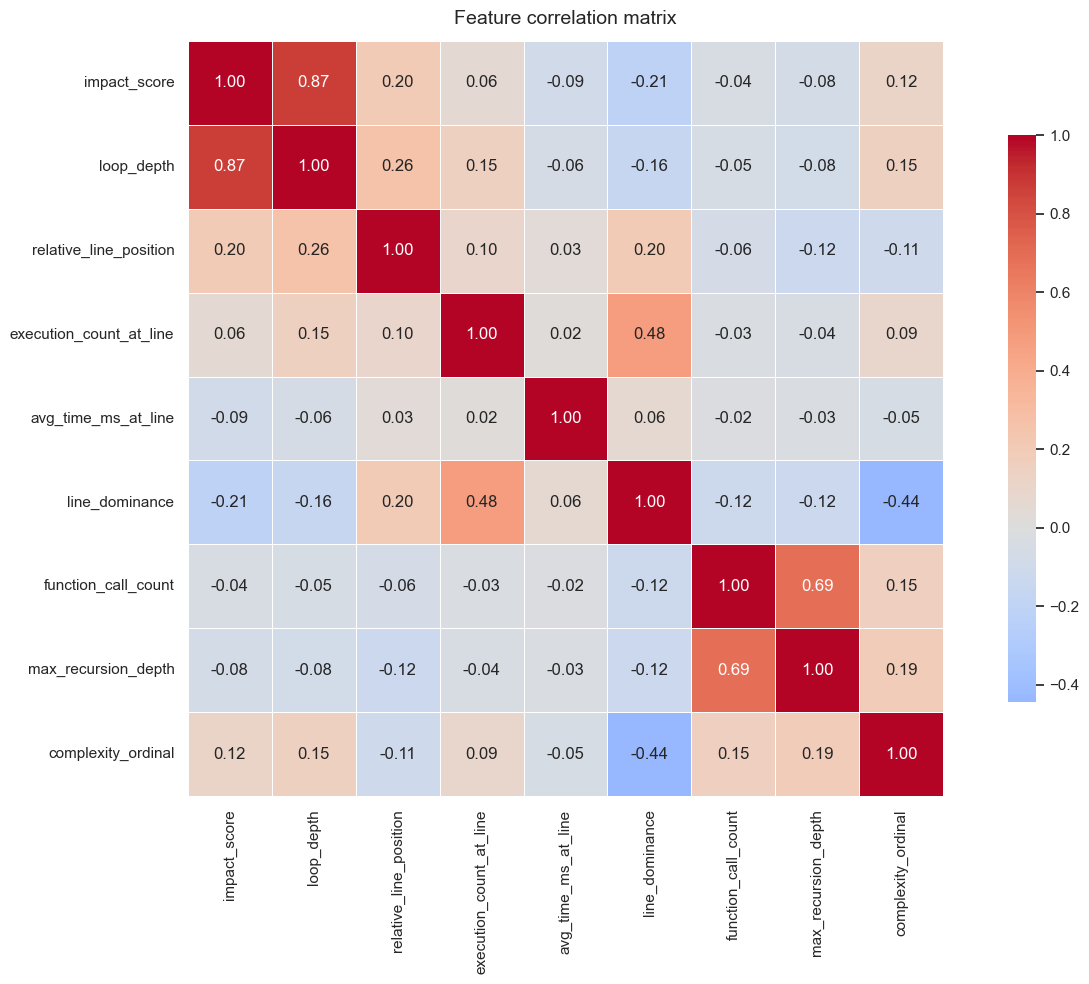

In [24]:
numeric_cols = df_clean.select_dtypes(include="number").drop(
    columns=["severity"], errors="ignore"  # already ordinal-encoded, keep if you want
).columns.tolist()

corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.75},
)
ax.set_title("Feature correlation matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "correlation_heatmap.png"), dpi=150)
plt.show()

#### Pattern frequency bar chart

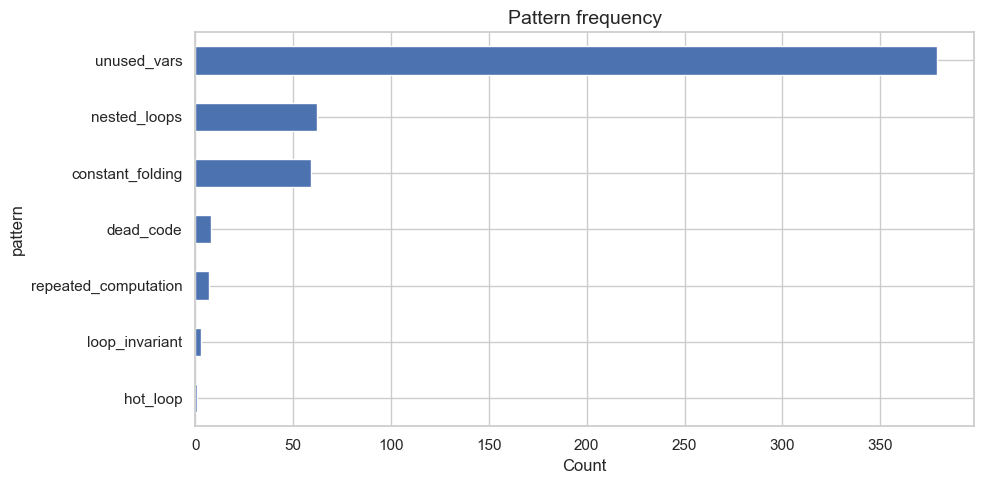

In [25]:
pat_freq = (
    df_clean["pattern_frequency"]
    .drop_duplicates()  # one value per pattern
    if "pattern_frequency" in df_clean.columns
    else None
)

pat_counts = df_raw["pattern"].value_counts()


fig, ax = plt.subplots(figsize=(10, 5))
pat_counts.sort_values(ascending=True).plot(
    kind="barh", ax=ax, color="#4C72B0", edgecolor="white"
)
ax.set_xlabel("Count")
ax.set_title("Pattern frequency", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "pattern_frequency.png"), dpi=150)
plt.show()


#### Key numeric feature distributions

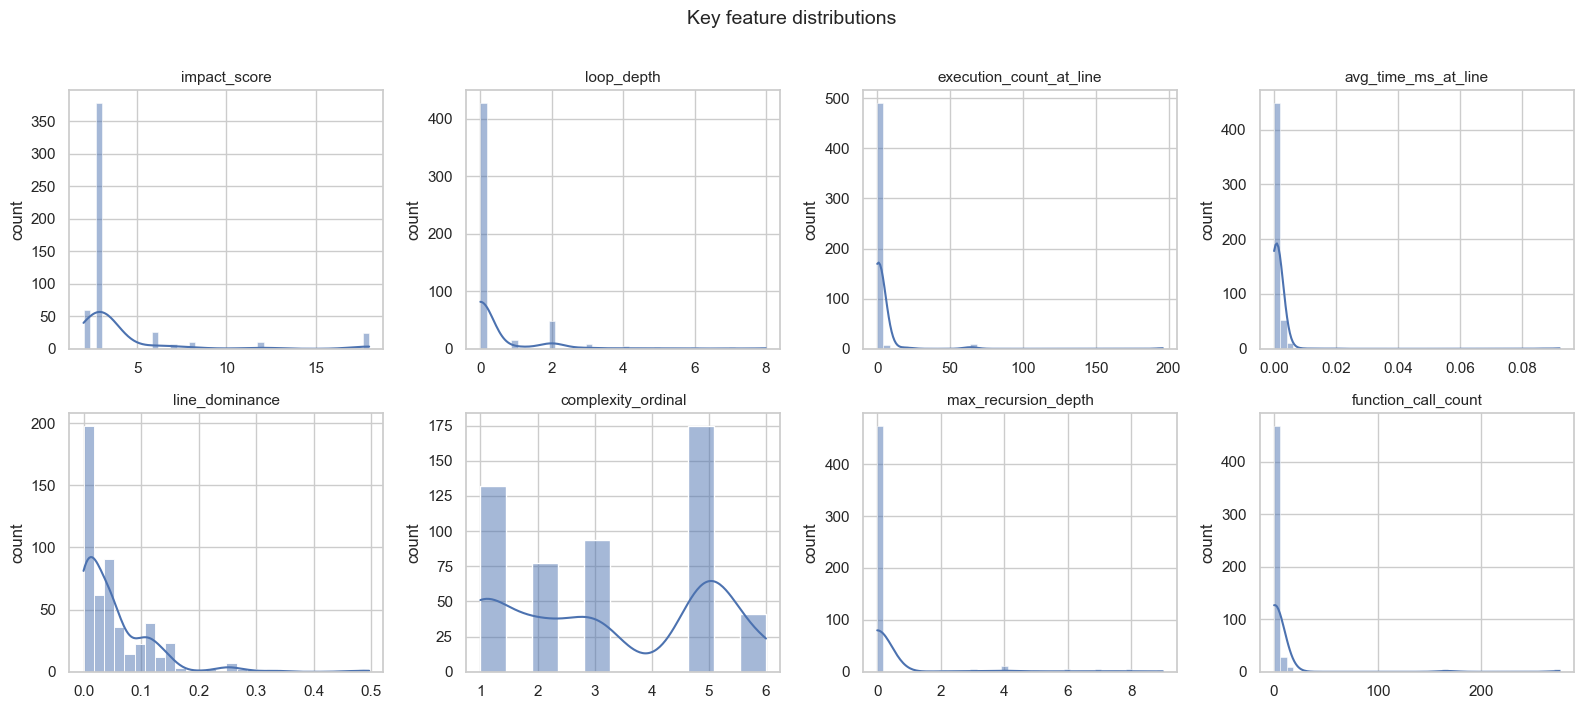

In [26]:
key_features = [
    "impact_score", "loop_depth", "execution_count_at_line",
    "avg_time_ms_at_line", "line_dominance", "complexity_ordinal",
    "max_recursion_depth", "function_call_count",
]
key_features = [f for f in key_features if f in df_clean.columns]

n = len(key_features)
ncols = 4
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.histplot(df_clean[feat], ax=axes[i], kde=True, color="#4C72B0")
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("count")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Key feature distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "feature_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

In [27]:
print("EDA completed")

EDA completed
